# **Import the libraries**

In [ ]:
import pandas as pd          
import numpy as np           
from sklearn.linear_model import LinearRegression   
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_absolute_error      
from sklearn.metrics import r2_score                 
from sklearn.metrics import mean_squared_error       
import matplotlib.pyplot as plt  
import seaborn as sns             
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("All libraries loaded successfully ✅")

# **Data Exploration**

## *Load The Data*

In [ ]:
df = pd.read_csv("C:\\Users\\abhay\\OneDrive\\Desktop\\ML learning\\Linear Regression\\Practice\\House Price\\Data\\house_price.csv")

## *Exploration*

In [ ]:
print(f"The Data Shape is {df.shape}")

In [ ]:
# First 5 Rows
df.head()

In [ ]:
# Last 5 rows
df.tail()

In [ ]:
df.info()

In [ ]:
df.describe()

## *Nulls & Duplicates*

In [ ]:
print("The NaN % the Data have is ")
print()
NaN = df.isna().sum()
print(round((NaN/len(df))*100,2))

In [ ]:
print(f"The Total Duplicates the Dataset have: {df.duplicated().sum()}")

# **Data Cleaning**

In [ ]:
# Create a copy of Original
df_copy = df.copy()
print("Cpoy Created!!")

## *Data Type correction*

In [ ]:
df_copy["age_years"]  = df_copy["age_years"].astype(dtype='int')
df_copy["floor_number"]  = df_copy["floor_number"].astype(dtype='int')
df_copy["has_parking"]  = df_copy["has_parking"].astype(dtype='bool')
df_copy["bedrooms"]  = df_copy["bedrooms"].astype(dtype='int')

## *Impossible Values*

In [ ]:
df_copy.loc[df_copy['age_years']<0,'age_years'] = np.nan 
df_copy.loc[df_copy['area_sqft']<=0,'area_sqft'] = np.nan 

## *Handling Missing Value*

In [ ]:
df_copy['area_sqft'] = df_copy['area_sqft'].fillna(df_copy['area_sqft'].median())
df_copy['distance_to_metro_km'] = df_copy['distance_to_metro_km'].fillna(df_copy['distance_to_metro_km'].median())
df_copy['price_lakh'] = df_copy['price_lakh'].fillna(df_copy['price_lakh'].median())
df_copy['age_years'] = df_copy['age_years'].fillna(df_copy['price_lakh'].median())

## *Handling outliers*

In [ ]:
Q1 = df_copy['price_lakh'].quantile(0.25)
Q3 = df_copy['price_lakh'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_copy.loc[df_copy['price_lakh'] < lower, 'price_lakh'] = np.nan
df_copy.loc[df_copy['price_lakh'] > upper, 'price_lakh'] = np.nan

## *Drop Duplicates*

In [ ]:
print("Before:", df_copy.shape)

df_copy.drop_duplicates(inplace=True)

print("After:", df_copy.shape)

## *Confirm Dataset*

In [ ]:
# Confirm
print("Final shape:", df_copy.shape)
print(df_copy.info())
print(df_copy.describe())

In [ ]:
df_copy.isna().sum()

# **Data Preperation**

In [ ]:
X = df_copy[['area_sqft','distance_to_metro_km','has_parking','bedrooms']]
Y = df_copy['price_lakh']

print("X shape:", X.shape)
print("y shape:", Y.shape)
print()
print("Features:")
print(X.head())

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                # features
    Y,                # target
    test_size=0.6,    # 40% goes to test
    random_state=42   # same split every time you run
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

In [ ]:
# Null values check
print("Nulls in X_train:", X_train.isnull().sum().sum())
print("Nulls in y_train:", y_train.isnull().sum())

# **Model**

## *Train*

In [ ]:
Model = LinearRegression()

In [ ]:
# Train the model 
Model.fit(X_train, y_train)

print("Model trained successfully ✅")

In [ ]:
# See What The Model Learned
print(f"Intercept (β₀): {Model.intercept_:.4f}")
print()
print("Feature Coefficients:")
for feature, coef in zip(X.columns, Model.coef_):
    print(f"  {feature:22} → {coef:.4f}")

## *Test*

In [ ]:
# Predict lap times for test set
y_pred = Model.predict(X_test)

# Compare actual vs predicted — first 10 rows
comparison = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred.round(3),
    'Difference': (y_test.values - y_pred).round(3)
})

print(comparison.head(10))

## *Evaluation*

In [ ]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:       {mae:.4f}")
print(f"RMSE:      {rmse:.4f}")
print(f"R² Score:  {r2:.4f}")

# **Visualisation**

## *Actual Vs Pridicted*

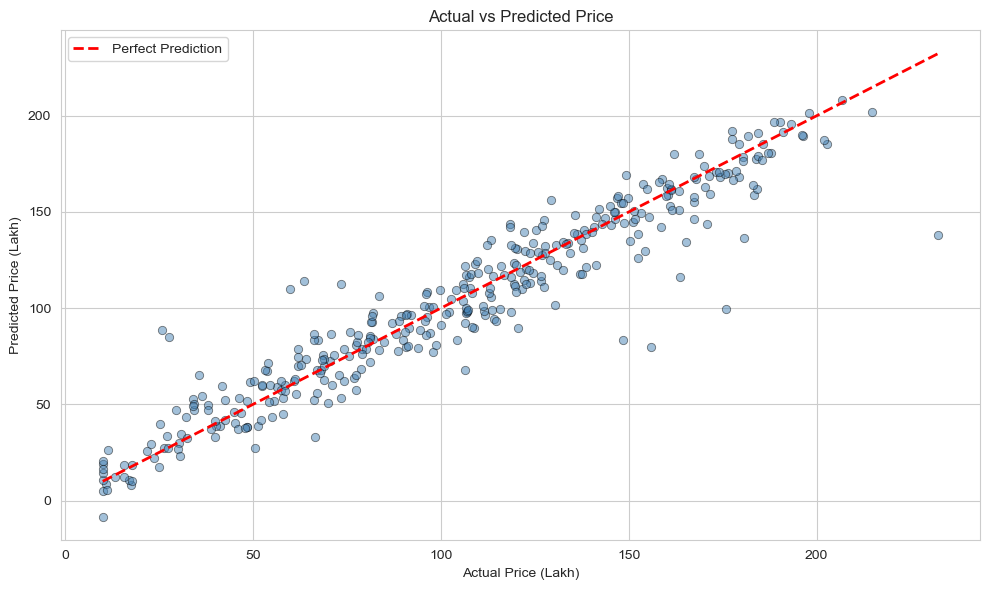

In [148]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, color='steelblue', alpha=0.5, edgecolors='black', linewidth=0.6)

# Perfect prediction line — if every prediction was exact
# all dots would sit on this line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Price (Lakh)')
plt.ylabel('Predicted Price (Lakh)')
plt.title('Actual vs Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()